# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/haritharamadass/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)



## 1. Distributions

### Distribution audit

Before deciding which search signals are useful, I inspect the distributions of the main March 2026 fields used in the project.

I focus on:

- `impressions_31d`
- `ctr_31d`
- `avg_position_31d`
- `active_gsc_days`

Search-performance variables can be strongly skewed, so I compare medians, upper percentiles, minimums, and maximums rather than relying only on averages. This helps prevent a small number of very large observations from driving the rule design.

Hugging Face access configured successfully.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Signal-audit frame
---------------------------------------------
Rows: 100,893
Clients: 43
Content items: 100,893

Distribution summary:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
impressions_31d,100893.0,2761.300952,6961.642086,100.000000,286.000000,794.000000,2532.000000,6444.800000,11150.000000,29413.960000,617124.000000
ctr_31d,100893.0,0.262004,0.419347,0.000000,0.000000,0.124844,0.367647,0.695652,0.961538,1.851852,15.584416
avg_position_31d,100893.0,14.463754,14.799159,0.019643,4.825503,8.324482,19.165980,34.287749,46.130879,71.106933,115.661538
active_gsc_days,100893.0,28.552377,4.959123,1.000000,29.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000



Skewness:


,skewness
impressions_31d,15.637529
ctr_31d,5.227283
avg_position_31d,2.003321
active_gsc_days,-2.652167


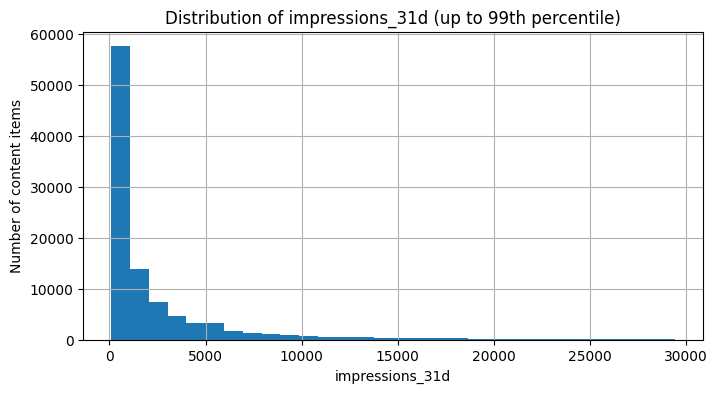

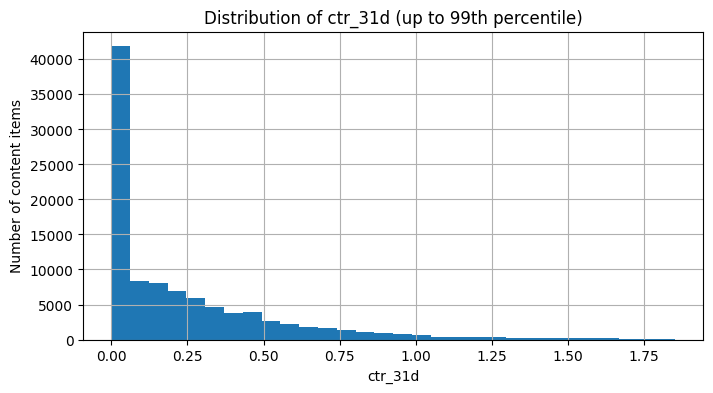

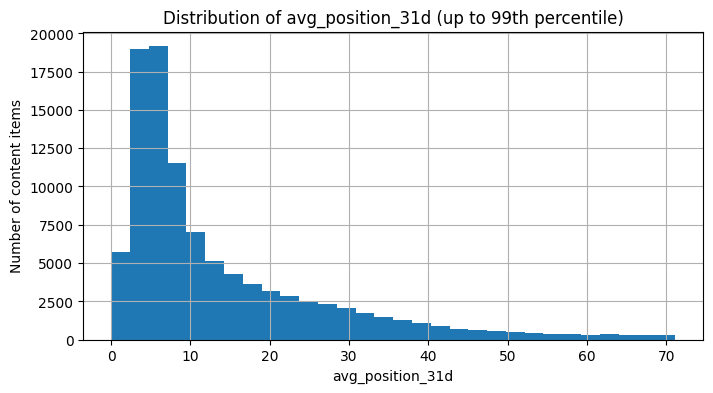

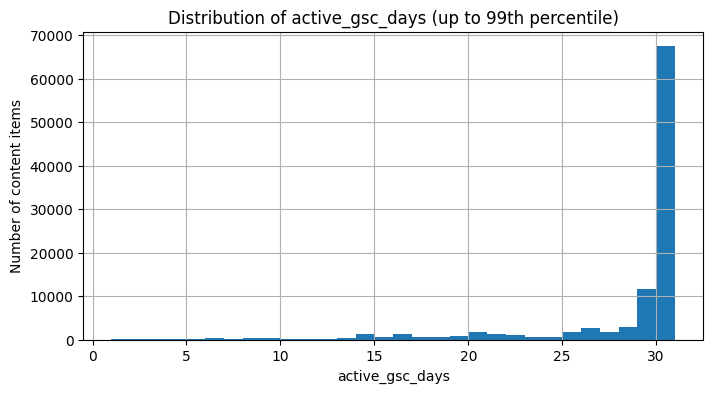


Distribution audit complete.
Large differences between the median, upper percentiles, and maximum indicate that some search-performance fields have heavy or skewed tails.


In [1]:
# ML-06 — Section 1
# Inspect distributions before deciding which signals to trust.

from google.colab import userdata
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Connect safely to the FlyRank warehouse
# ---------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "HF_TOKEN was not found. Add your Hugging Face READ token "
        "to Colab Secrets first."
    )

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

print("Hugging Face access configured successfully.")

MARCH = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

APRIL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet'
)
"""

# ---------------------------------------------------------
# Build the same analytical frame used by the capstone
# ---------------------------------------------------------

signal_data = con.sql(f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS impressions_31d,

        SUM(gsc_clicks) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS clicks_31d,

        SUM(gsc_avg_position * gsc_impressions) FILTER (
            WHERE gsc_data_available IS TRUE
              AND gsc_impressions > 0
              AND gsc_avg_position > 0
        )
        /
        NULLIF(
            SUM(gsc_impressions) FILTER (
                WHERE gsc_data_available IS TRUE
                  AND gsc_impressions > 0
                  AND gsc_avg_position > 0
            ),
            0
        ) AS avg_position_31d,

        COUNT(*) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS active_gsc_days

    FROM {MARCH}

    GROUP BY
        client_hash_id,
        content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS april_impressions,

        COUNT(*) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS april_gsc_days

    FROM {APRIL}

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,
    m.impressions_31d,

    100.0 * m.clicks_31d
        / NULLIF(m.impressions_31d, 0) AS ctr_31d,

    m.avg_position_31d,
    m.active_gsc_days,

    CASE
        WHEN a.april_impressions < 0.80 * m.impressions_31d
        THEN 1
        ELSE 0
    END AS declined_next_month

FROM march m

INNER JOIN april a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id

WHERE
    m.impressions_31d >= 100
    AND m.avg_position_31d IS NOT NULL
    AND m.avg_position_31d > 0
    AND m.active_gsc_days > 0
    AND a.april_gsc_days > 0
    AND a.april_impressions IS NOT NULL
""").df()

KEY_FIELDS = [
    "impressions_31d",
    "ctr_31d",
    "avg_position_31d",
    "active_gsc_days"
]

signal_data = signal_data.dropna(
    subset=KEY_FIELDS + ["declined_next_month"]
).reset_index(drop=True)

print("\nSignal-audit frame")
print("---------------------------------------------")
print(f"Rows: {len(signal_data):,}")
print(f"Clients: {signal_data['client_hash_id'].nunique():,}")
print(f"Content items: {signal_data['content_hash_id'].nunique():,}")

# ---------------------------------------------------------
# Distribution summary
# ---------------------------------------------------------

distribution_summary = signal_data[KEY_FIELDS].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

print("\nDistribution summary:")
display(distribution_summary)

print("\nSkewness:")
display(
    signal_data[KEY_FIELDS]
    .skew()
    .sort_values(ascending=False)
    .to_frame("skewness")
)

# ---------------------------------------------------------
# Histograms
# Use the 99th percentile for display so extreme tails
# do not hide the shape of the main population.
# ---------------------------------------------------------

for field in KEY_FIELDS:
    upper = signal_data[field].quantile(0.99)

    plt.figure(figsize=(8, 4))
    signal_data.loc[
        signal_data[field] <= upper, field
    ].hist(bins=30)

    plt.title(f"Distribution of {field} (up to 99th percentile)")
    plt.xlabel(field)
    plt.ylabel("Number of content items")
    plt.show()

print("\nDistribution audit complete.")
print(
    "Large differences between the median, upper percentiles, "
    "and maximum indicate that some search-performance fields "
    "have heavy or skewed tails."
)

### Distribution findings

The March search-performance variables are not evenly distributed. `impressions_31d` is especially right-skewed: the median is 794 impressions, while the mean is about 2,761 and the 99th percentile is about 29,414. This shows that a relatively small number of content items receive very large search volumes.

`ctr_31d` and `avg_position_31d` also have right-skewed distributions. In contrast, `active_gsc_days` is concentrated near the full 31-day month, with most eligible items having strong data coverage.

Because of these skewed distributions, I use bucket-based comparisons and medians where appropriate instead of relying only on overall averages.

## 2. Signal test #1 / #2 / #3 (verdict each)

### Three signal tests

I test three public-safe March signals before using them in a ranking rule.

1. **Search position vs CTR** — better search positions should generally be associated with stronger CTR.
2. **Search impression volume** — higher-volume content may deserve greater review attention because more visibility is at stake.
3. **GSC coverage** — the number of active GSC days may affect how reliable the observed monthly signals are.

For each test I compare groups rather than assuming that the expected relationship must hold. The final verdict will be recorded as CONFIRMED, OPPOSITE, MIXED, or FALSE based on the observed data.

In [2]:
# ML-06 — Section 2
# Three public-safe signal mini-tests.

import numpy as np
import pandas as pd

audit = signal_data.copy()

print("=" * 70)
print("SIGNAL 1 — SEARCH POSITION VS CTR")
print("=" * 70)

# Search-position buckets
audit["position_bucket"] = pd.cut(
    audit["avg_position_31d"],
    bins=[0, 3, 10, 20, 50, np.inf],
    labels=["<=3", "4-10", "11-20", "21-50", "51+"],
    include_lowest=True
)

signal_1 = (
    audit.groupby("position_bucket", observed=True)
    .agg(
        n=("content_hash_id", "size"),
        median_ctr=("ctr_31d", "median"),
        mean_ctr=("ctr_31d", "mean"),
        decline_rate=("declined_next_month", "mean")
    )
    .reset_index()
)

signal_1["median_ctr"] = signal_1["median_ctr"].round(3)
signal_1["mean_ctr"] = signal_1["mean_ctr"].round(3)
signal_1["decline_rate"] = (100 * signal_1["decline_rate"]).round(2)

display(signal_1)


print("\n" + "=" * 70)
print("SIGNAL 2 — SEARCH IMPRESSION VOLUME")
print("=" * 70)

# Interpretable impression-volume buckets
audit["impression_bucket"] = pd.cut(
    audit["impressions_31d"],
    bins=[99, 499, 999, 4999, 9999, np.inf],
    labels=[
        "100-499",
        "500-999",
        "1,000-4,999",
        "5,000-9,999",
        "10,000+"
    ],
    include_lowest=True
)

signal_2 = (
    audit.groupby("impression_bucket", observed=True)
    .agg(
        n=("content_hash_id", "size"),
        median_impressions=("impressions_31d", "median"),
        decline_rate=("declined_next_month", "mean")
    )
    .reset_index()
)

signal_2["median_impressions"] = (
    signal_2["median_impressions"].round(0).astype(int)
)
signal_2["decline_rate"] = (100 * signal_2["decline_rate"]).round(2)

display(signal_2)


print("\n" + "=" * 70)
print("SIGNAL 3 — ACTIVE GSC DAYS")
print("=" * 70)

audit["coverage_bucket"] = pd.cut(
    audit["active_gsc_days"],
    bins=[0, 14, 20, 25, 28, 30, 31],
    labels=[
        "1-14 days",
        "15-20 days",
        "21-25 days",
        "26-28 days",
        "29-30 days",
        "31 days"
    ],
    include_lowest=True
)

signal_3 = (
    audit.groupby("coverage_bucket", observed=True)
    .agg(
        n=("content_hash_id", "size"),
        median_impressions=("impressions_31d", "median"),
        median_ctr=("ctr_31d", "median"),
        decline_rate=("declined_next_month", "mean")
    )
    .reset_index()
)

signal_3["median_impressions"] = (
    signal_3["median_impressions"].round(0).astype(int)
)
signal_3["median_ctr"] = signal_3["median_ctr"].round(3)
signal_3["decline_rate"] = (100 * signal_3["decline_rate"]).round(2)

display(signal_3)

print("\nThree signal tables created successfully.")
print("I will assign the verdicts only after inspecting these observed results.")

SIGNAL 1 — SEARCH POSITION VS CTR


,position_bucket,n,median_ctr,mean_ctr,decline_rate
0,<=3,9732,0.219,0.347,55.39
1,4-10,47445,0.192,0.321,50.90
2,11-20,19678,0.100,0.244,52.11
3,21-50,19913,0.000,0.142,49.81
4,51+,4125,0.000,0.046,54.11



SIGNAL 2 — SEARCH IMPRESSION VOLUME


,impression_bucket,n,median_impressions,decline_rate
0,100-499,39047,227,53.85
1,500-999,16820,701,53.65
2,"1,000-4,999",31736,2072,49.46
3,"5,000-9,999",7413,6752,48.29
4,"10,000+",5877,16156,44.55



SIGNAL 3 — ACTIVE GSC DAYS


,coverage_bucket,n,median_impressions,median_ctr,decline_rate
0,1-14 days,3684,308,0.196,18.02
1,15-20 days,5466,351,0.137,32.78
2,21-25 days,5320,306,0.071,40.58
3,26-28 days,7265,191,0.000,53.26
4,29-30 days,17459,367,0.000,48.19
5,31 days,61699,1359,0.150,56.80



Three signal tables created successfully.
I will assign the verdicts only after inspecting these observed results.


### Signal verdicts

**Signal 1 — Search position vs CTR: CONFIRMED.**  
The observed CTR becomes lower as average search position worsens. Median CTR is 0.219 for positions 1–3, 0.192 for positions 4–10, 0.100 for positions 11–20, and approximately zero in the lower-position groups. This supports the expected relationship between stronger search position and stronger CTR.

**Signal 2 — Search impression volume: OPPOSITE.**  
Higher impression volume is not associated with a higher future-decline rate in this sample. The decline rate falls from 53.85% in the 100–499 impression group to 44.55% among items with 10,000+ impressions. High-volume content may still deserve early review because more visibility is at stake, but volume alone should not be interpreted as greater decline risk.

**Signal 3 — Active GSC days: MIXED.**  
Items with more complete GSC coverage generally show higher observed decline rates, but the relationship is not perfectly monotonic. Coverage therefore matters for interpreting the monthly measurements, but active GSC days should not be treated as a simple independent decline-risk rule.

These are observed associations and are used only as directional decision-support evidence.

## 3. The flag-linked test

### Flag-linked test: low CTR relative to search position

One of FlyRank's real review signals is CTR relative to search position. A page may rank reasonably well but still receive fewer clicks than similar pages at comparable positions.

To test this assumption without using a fixed arbitrary CTR threshold, I compare each item's CTR with the median CTR of its search-position bucket. An item is marked `LOW_CTR_FOR_POSITION` when its CTR is below the median for other items in the same position group.

I then compare the observed next-month decline rate for flagged and non-flagged items. This test evaluates whether the flag is useful as a review signal; it does not prove that low CTR causes a future decline.

In [3]:
# ML-06 — Section 3
# Test a real flag-linked signal: LOW_CTR_FOR_POSITION

flag_test = audit.copy()

# Median CTR within each search-position bucket
bucket_ctr_median = (
    flag_test.groupby("position_bucket", observed=True)["ctr_31d"]
    .transform("median")
)

# Flag pages whose CTR is below peers in the same position bucket
flag_test["low_ctr_for_position"] = (
    flag_test["ctr_31d"] < bucket_ctr_median
)

flag_summary = (
    flag_test.groupby("low_ctr_for_position")
    .agg(
        n=("content_hash_id", "size"),
        median_ctr=("ctr_31d", "median"),
        median_position=("avg_position_31d", "median"),
        decline_rate=("declined_next_month", "mean")
    )
    .reset_index()
)

flag_summary["flag_status"] = flag_summary[
    "low_ctr_for_position"
].map({
    False: "NOT FLAGGED",
    True: "LOW_CTR_FOR_POSITION"
})

flag_summary["median_ctr"] = flag_summary["median_ctr"].round(3)
flag_summary["median_position"] = flag_summary[
    "median_position"
].round(2)

flag_summary["decline_rate"] = (
    100 * flag_summary["decline_rate"]
).round(2)

flag_summary = flag_summary[
    [
        "flag_status",
        "n",
        "median_ctr",
        "median_position",
        "decline_rate"
    ]
]

print("Flag-linked test — CTR relative to search position")
print("-" * 65)

display(flag_summary)

flagged_rate = flag_summary.loc[
    flag_summary["flag_status"] == "LOW_CTR_FOR_POSITION",
    "decline_rate"
].iloc[0]

not_flagged_rate = flag_summary.loc[
    flag_summary["flag_status"] == "NOT FLAGGED",
    "decline_rate"
].iloc[0]

difference = flagged_rate - not_flagged_rate

print(f"\nFlagged decline rate: {flagged_rate:.2f}%")
print(f"Not-flagged decline rate: {not_flagged_rate:.2f}%")
print(f"Difference: {difference:+.2f} percentage points")

print("\nInterpretation:")
print(
    "This is an observational flag audit. A difference in future decline "
    "rate can support or weaken the rule as a review signal, but it does "
    "not establish that low CTR causes impression decline."
)

Flag-linked test — CTR relative to search position
-----------------------------------------------------------------


,flag_status,n,median_ctr,median_position,decline_rate
0,NOT FLAGGED,62467,0.291,11.79,45.06
1,LOW_CTR_FOR_POSITION,38426,0.000,6.66,61.93



Flagged decline rate: 61.93%
Not-flagged decline rate: 45.06%
Difference: +16.87 percentage points

Interpretation:
This is an observational flag audit. A difference in future decline rate can support or weaken the rule as a review signal, but it does not establish that low CTR causes impression decline.


## 4. What this means in practice

### Practical takeaway

The signal audit shows that CTR relative to search position is useful for prioritizing human review. Content flagged as `LOW_CTR_FOR_POSITION` had a future decline rate of 61.93%, compared with 45.06% for non-flagged content, a difference of 16.87 percentage points.

A content team can therefore use this flag as one reason to inspect a page earlier, especially when the page already has meaningful search visibility. However, the signal should support human diagnosis rather than trigger automatic editing because the relationship is observational and does not prove that low CTR causes the future decline.

The broader audit also shows that impression volume should not be treated as a simple decline-risk signal, and data coverage should be interpreted cautiously.

In [4]:
# ML-06 — Section 4
# Summarize the practical decision-support takeaway.

final_verdicts = pd.DataFrame([
    {
        "signal": "Search position vs CTR",
        "verdict": "CONFIRMED",
        "practical_use": "Use position-relative CTR as a review signal."
    },
    {
        "signal": "Search impression volume",
        "verdict": "OPPOSITE",
        "practical_use": "Use volume for impact/prioritization, not as proof of higher decline risk."
    },
    {
        "signal": "Active GSC days",
        "verdict": "MIXED",
        "practical_use": "Use coverage to judge reliability, not as a simple standalone risk rule."
    },
    {
        "signal": "LOW_CTR_FOR_POSITION flag",
        "verdict": "CONFIRMED",
        "practical_use": "Flagged content deserves earlier human review."
    }
])

print("Final signal-audit verdicts")
print("---------------------------------------------")
display(final_verdicts)

print("\nFlag-linked result:")
print("LOW_CTR_FOR_POSITION decline rate: 61.93%")
print("Not-flagged decline rate: 45.06%")
print("Difference: +16.87 percentage points")

print("\nPractical takeaway:")
print(
    "Use LOW_CTR_FOR_POSITION as a directional human-review signal, "
    "not as proof that low CTR causes impression decline."
)

print("\nPublic-safety statement:")
print(
    "All conclusions are observational, measured, directional, "
    "and intended for decision support only."
)

Final signal-audit verdicts
---------------------------------------------


,signal,verdict,practical_use
0,Search position vs CTR,CONFIRMED,Use position-relative CTR as a review signal.
1,Search impression volume,OPPOSITE,"Use volume for impact/prioritization, not as p..."
2,Active GSC days,MIXED,"Use coverage to judge reliability, not as a si..."
3,LOW_CTR_FOR_POSITION flag,CONFIRMED,Flagged content deserves earlier human review.



Flag-linked result:
LOW_CTR_FOR_POSITION decline rate: 61.93%
Not-flagged decline rate: 45.06%
Difference: +16.87 percentage points

Practical takeaway:
Use LOW_CTR_FOR_POSITION as a directional human-review signal, not as proof that low CTR causes impression decline.

Public-safety statement:
All conclusions are observational, measured, directional, and intended for decision support only.
